## SECTION 5.1 텍스트 생성 모델 평가하기

- 이 절의 목표
    - ![5-2](img/5-1.png)
    - 텍스트 생성 위해 LLM 준비
    - 생성된 텍스트 품질 평가하는 기본적 방법 소개
    - 훈련 손실 & 검증 손실 계산

### 5.1.1 GPT 사용해 텍스트 생성하기

In [1]:
import torch
from Chapter04_git import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # 어휘 사전 크기
    "context_length": 256,  # 짧은 문맥 길이 축소 (원본 길이: 1024) -> 모델 훈련 시 필요한 자원 감소
    "emb_dim": 768,         # 임베딩 차원
    "n_heads": 12,          # 어텐션 헤드 개수
    "n_layers": 12,         # 층 개수
    "drop_rate": 0.1,       # 드롭아웃 비율
    "qkv_bias": False       # 쿼리-키-값 생성시 편향 사용 여부
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # 추론 시 드롭아웃을 비활성화

- 텍스트 생성 3단계
    1. 토크나이저가 입력 텍스트 일련의 토큰 ID로 변환
    2. 모델이 토큰 ID 받아 로짓(어휘 사전에 있는 각 토큰에 대한 확률 분포 나타내는 벡터) 생성
    3. 로짓 다시 토큰 ID로 변환 -> 토크나이저가 토큰 ID를 텍스트로 디코딩
    - ![5-3](img/5-3.png)

In [2]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx는 현재 문맥이 담긴 (batch, n_tokens) 크기의 인덱스 배열입니다
    for _ in range(max_new_tokens):

        # 현재 문맥이 모델이 지원하는 문맥 크기를 초과하면 잘라냅니다.
        # 예를 들어, LLM이 5개 토큰만 지원하고 문맥 크기가 10이라면,
        # 마지막 5개 토큰만 문맥으로 사용합니다.
        idx_cond = idx[:, -context_size:]

        # 예측을 만듭니다.
        with torch.no_grad():
            logits = model(idx_cond)

        # 마지막 타임 스텝만 사용하므로
        # (batch, n_token, vocab_size)가 (batch, vocab_size)가 됩니다.
        logits = logits[:, -1, :]

        # 확률을 얻기 위해 소프트맥스를 적용합니다.
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # 가장 높은 확률 값을 가진 항목의 인덱스를 얻습니다.
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # 선택한 인덱스를 현재 시퀀스에 추가합니다.
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx

In [3]:
import tiktoken

# 텍스트 -> 토큰 ID 텐서
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 배치 차원을 추가합니다.
    return encoded_tensor

# 토큰 ID -> 텍스트
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # 배치 차원을 삭제합니다
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### 5.1.2 텍스트 생성 손실 계산

- LLM이 입력 텍스트 받아 텍스트 생성하는 전반적 흐름
    - ![5-4](img/5-4.png)

In [4]:
inputs = torch.tensor([[16833, 3626, 6100],     # ["every effort moves",
                       [40,    1107, 588]])     #  "I really like"]

In [5]:
# targets: 한 위치 이동한 입력
targets = torch.tensor([[3626, 6100, 345  ],    # [" effort moves you",
                        [1107,  588, 11311]])   #  " really like chocolate"]

In [6]:
# 각각 3개 토큰으로 구성된 입력 샘플 2개에 대한 로짓 벡터 계산
with torch.no_grad():
    logits = model(inputs)

# softmax 함수 적용 -> 로짓을 확률 점수로 변환
probas = torch.softmax(logits, dim=-1)      # 어휘 사전의 각 토큰에 대한 확률
print(probas.shape)                         # 크기: (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


- torch.Size([2, 3, 50257])
    - 2: 샘플 2개
    - 3: 각 입력(행)의 토큰 개수
    - 50257: 임베딩 차원

In [7]:
# argmax: 가장 큰 값(확률) 가진 위치 고름
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("토큰 ID:\n", token_ids)

토큰 ID:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [8]:
# 토큰 ID -> 텍스트 변환

print(f"첫 번째 샘플의 타깃: {token_ids_to_text(targets[0], tokenizer)}")
print(f"첫 번째 샘플의 출력:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

print(f"두 번째 샘플의 타깃: {token_ids_to_text(targets[1], tokenizer)}")
print(f"두 번째 샘플의 출력:"
      f" {token_ids_to_text(token_ids[1].flatten(), tokenizer)}")

첫 번째 샘플의 타깃:  effort moves you
첫 번째 샘플의 출력:  Armed heNetflix
두 번째 샘플의 타깃:  really like chocolate
두 번째 샘플의 출력:  pressuring empoweredfaith


- 모델 훈련X -> 생성되길 기대했던 타깃과 다름
- 훈련 위해 정답 예측(타깃)에서 얼만큼 떨어져있는지 알아야함

- 훈련 전에는 모델이 랜덤하게 다음 토큰 확률 벡터를 만듦
    - 아래 예시는 7개 토큰 가진 어휘사전에 대한 소프트맥스 확률
        - ![5-6](img/5-6.png)
    - GPT-2의 경우 50,256개 토큰 -> 초기 확률 대부분 0.00002(1/50257)
    - 모델 훈련 목적: 타깃 토큰 ID에 해당하는 확률 값 최대화

In [9]:
# 두 샘플에 대한 3개의 타깃 토큰 확률
# 확률이 1에 가까워지도록 이 값들 최대화하는 것이 목표

text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]    # [2, 3, 50257]
print("텍스트 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("텍스트 2:", target_probas_2)

텍스트 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
텍스트 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [10]:
# 토큰 확률의 로그 계산
# 확률이 작을 때 로그값은 큰 음수 -> 모델이 정답에 낮은 확률 주면 로그 확률 매우 낮아짐
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [11]:
# 각 토큰에 대한 평균 확률 계산
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [12]:
# 모델 가중치 업데이트 -> 평균 로그 확률 0에 가깝게 만드는 것이 목표
# 딥러닝에서는 일반적으로 음의 평균 로그 확률을 0으로 만듦
    # 음의 평균 로그 확률: 평균 로그 확률 × -1
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


- 크로스 엔트로피: 정답과 예측 확률이 얼마나 다른지 측정하는 값
    - 평균 로그 확률을 음의 로그 확률로 바꾸어줌
- 파이토치의 `cross_entropy` 함수
    1. 로짓
    2. 확률
    3. 타깃 토큰 확률
    4. 로그 확률
    5. 평균 로그 확률
    6. 음의 평균 로그 확률
    - 위 6단계 모두 처리

In [13]:
# cross_entropy 함수 적용 전 로짓 & 타깃 텐서 크기 확인

print("로짓 크기:", logits.shape)       # (batch_size, num_tokens, vocab_size)
print("타깃 크기:", targets.shape)      # (batch_size, num_tokens)

로짓 크기: torch.Size([2, 3, 50257])
타깃 크기: torch.Size([2, 3])


In [14]:
# 파이토치 cross_entropy 손실 함수 위해 처음 두 차원 결합 -> 두 텐서 펼침

logits_flat = logits.flatten(0, 1)      # softmax 전의 정규화되지 않은 모델 출력
targets_flat = targets.flatten()        # 모델이 생성하길 기대하는 토큰 ID
print("펼친 로짓:", logits_flat.shape)
print("펼친 타깃:", targets_flat.shape)

펼친 로짓: torch.Size([6, 50257])
펼친 타깃: torch.Size([6])


In [15]:
# 파이토치의 cross_entropy 함수 사용

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


### 5.1.3 훈련 세트 & 검증 세트의 손실 계산

In [16]:
# 텍스트 데이터셋 로드

file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

In [17]:
# 데이터셋의 문자 & 토큰 수 확인

total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("문자:", total_characters)
print("토큰:", total_tokens)

문자: 20479
토큰: 5145


- 데이터 로더 만들기
    - ![5-9](img/5-9.png)
    1. 입력 텍스트를 훈련 세트 & 검증 세트로 분할
    2. 텍스트 토큰화
    3. 토큰화된 텍스트를 사용자가 지정한 길이(그림상 6, 코드상 256)
    4. 모델이 훈련에 사용할 수 있도록 행 섞고 텍스트 샘플을 배치로 모음

In [18]:
# 데이터 분할 & 로딩 구현 위해 train_ratio 0.9 지정 -> 90% 훈련 데이터, 10% 검증 데이터

train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [19]:
# 데이터 로더 만들기

from Chapter04_git import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [20]:
# 데이터 로더 순회하며 올바르게 만들어졌는지 확인

print("훈련 데이터 로더:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\n검증 데이터 로더:")
for x, y in val_loader:
    print(x.shape, y.shape)

# 9개 훈련 세트 배치, 1개 검증 세트 배치
# 각 배치에는 2개 샘플, 각 샘플 256개 토큰 구성

훈련 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

검증 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])


In [21]:
# 한 배치에 대한 크로스 엔트로피 손실 계산

def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

In [22]:
# 전체 데이터 로더 손실 계산 함수

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.

    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)      # num_batches 지정X 시 모든 배치 순회
    else:
        # num_batches가 데이터 로더에 있는 배치 개수보다 크면 배치 횟수를 데이터 로더에 있는 총 배치 개수로 맞춤
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()       # 각 배치의 손실 더함
        else:
            break
    return total_loss / num_batches         # 모든 배치의 손실 평균

In [23]:
# calc_loss_loader 함수 실행

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)    # CUDA 지원 GPU 있다면 GPU에서 LLM 훈련

torch.manual_seed(123) # 데이터 로더에서 셔플링이 일어나므로 재현가능성을 위해 설정합니다.

with torch.no_grad(): # 모델을 아직 훈련하지 않으므로 효율성을 위해 그레이디언트 추적을 끕니다.
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("훈련 손실:", train_loss)
print("검증 손실:", val_loss)

# 모델 아직 훈련X -> 손실값 비교적 높음

훈련 손실: 10.98758347829183
검증 손실: 10.98110580444336


## SECTION 5.2 LLM 훈련하기

- 파이토치 신경망 훈련 워크플로
    - ![5-11](img/5-11.png)

In [24]:
# LLM 사전 훈련 위한 함수

def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):

    train_losses, val_losses, track_tokens_seen = [], [], []    # 손실과 지금까지 처리한 토큰 수 추적 위해 리스트를 초기화
    tokens_seen, global_step = 0, -1

    # 메인 훈련 루프 시작
    for epoch in range(num_epochs):
        model.train()  # 모델 훈련 모드로 설정

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   # 이전 배치 반복에서 얻은 손실의 그레이디언트 초기화
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()     # 손실 그레이디언트 계산
            optimizer.step()    # 손실 그레이디언트를 사용 -> 모델 가중치 업데이트
            tokens_seen += input_batch.numel()
            global_step += 1

            # 추가적인 평가 단계
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"에포크 {epoch+1} (Step {global_step:06d}): "
                      f"훈련 손실 {train_loss:.3f}, 검증 손실 {val_loss:.3f}")

        # 각 에포크 후 샘플 텍스트를 출력
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


# 모델을 평가 모드로 설정 -> 그레디언트 추적 & 드롭아웃 비활성화, 훈련 세트 & 검증 세트에 대한 손실 계산
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()        # 안정적이고 재현 가능한 결과 위해 평가 동안 드롭아웃 비활성화
    with torch.no_grad():   # 계산 오버헤드 줄이기 위해 훈련 과정에서 필요치 않은 그레디언트 추적 비활성화
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


# 모델이 훈련 과정에서 향상되었는지 추적 위해 만든 함수
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # 간결한 출력 포맷
    model.train()

In [25]:
# GPTModel 객체를 10 에포크 동안 훈련

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),     # parameters() 메서드: 모델에 있는 훈련 가능한 모든 가중치 파라미터 반환
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

에포크 1 (Step 000000): 훈련 손실 9.781, 검증 손실 9.933
에포크 1 (Step 000005): 훈련 손실 8.111, 검증 손실 8.339
Every effort moves you,,,,,,,,,,,,.                                     
에포크 2 (Step 000010): 훈련 손실 6.661, 검증 손실 7.048
에포크 2 (Step 000015): 훈련 손실 5.961, 검증 손실 6.616
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
에포크 3 (Step 000020): 훈련 손실 5.726, 검증 손실 6.600
에포크 3 (Step 000025): 훈련 손실 5.201, 검증 손실 6.348
Every effort moves you, and I had been.                                            
에포크 4 (Step 000030): 훈련 손실 4.417, 검증 손실 6.278
에포크 4 (Step 000035): 훈련 손실 4.069, 검증 손실 6.226
Every effort moves you know the                          "I he had the donkey and I had the and I had the donkey and down the room, I had
에포크 5 (Step 000040): 훈련 손실 3.732, 검증 손실 6.160
Every effort moves you know it was not that the picture--I had the fact by the last I had been--his, and in the            "Oh, and he said, and d

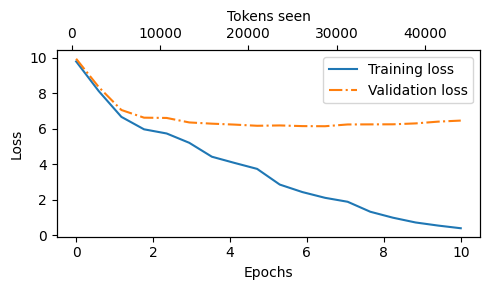

In [26]:
# 훈련 세트 손실 & 검증 세트 손실 나타내는 그래프

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 에포크에 대한 훈련 손실과 검증 손실의 그래프를 그립니다.
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # 처리한 토큰 수에 대한 두 번째 x 축을 만듭니다.
    ax2 = ax1.twiny()  # y 축을 공유하는 두 번째 x 축을 만듭니다.
    ax2.plot(tokens_seen, train_losses, alpha=0)  # 눈금을 정렬하기 위해 투명한 그래프를 만듭니다.
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

- 매우 작은 훈련 세트 사용 -> 훈련 데이터 그대로 암기해버리는 현상 예상 가능(과대적합)
- 일반적 LLM 모델: 헐씬 큰 데이터셋에서 딱 한 번의 에포크 동안 훈련

## SECTION 5.3 무작위성 제어 위한 디코딩 전략

In [27]:
# GPU에서 CPU로 옮김
model.to("cpu")
model.eval()

# GPTModel의 객체를 generate_text_simple 함수에 전달 -> 한 번에 하나의 토큰씩 텍스트 생성
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you know," was one of the axioms he laid down across the Sevres and silver of an exquisitely appointed lun


- `generate_text_simple`
    - 한 번에 하나의 단어(토큰)씩 새로운 텍스트 생성
    - 다음 토큰: 어휘 사전의 모든 토큰 중 확률 점수 가장 높은 토큰
    - 함수 여러 번 실행해도 항상 동일한 출력 생성
    - 온도 스케일링 & 탑-k 샘플링 사용해 텍스트의 무작위성 & 다양성 조절 가능

### 5.3.1 온도 스케일링

- 온도 스케일링
    - 토큰 생성 작업에 확률적 선택 과정 추가
    - 그리디 디코딩: 항상 가장 높은 확률 가진 토큰을 다음 토큰으로 선택
    - 다양성 더 높은 텍스트 생성 위해 argmax를 확률분포로부터 샘플링

In [28]:
# 매우 작은 어휘 사진

vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}
inverse_vocab = {v: k for k, v in vocab.items()}

In [29]:
# LLM이 시작 문맥으로 "every effort moves you" 받고 다음과 같은 로짓 생성했음 가정
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

# 그리디 디코딩
probas = torch.softmax(next_token_logits, dim=0)    # softmax 함수 통해 확률로 변환
next_token_id = torch.argmax(probas).item()         # argmax 함수 통해 생성 토큰에 해당하는 토큰 ID 획득

# 생성될 토큰
print(inverse_vocab[next_token_id])

forward


In [30]:
# 확률적 샘플링 과정 구현 위해 argmax를 파이토치의 multinomial 함수로 변경

torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

# 이전과 동일하게 forward
# ∵ forward가 가장 가능성 높은 토큰이기 때문에 대부분 multinomial 함수에 의해 선택됨

forward


In [31]:
# 샘플링 1000번 수행하여 검증

def print_sampled_tokens(probas):
    torch.manual_seed(123) # 재현가능성을 위한 랜덤 시드
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


- 온도 스케일링
    - 로짓을 0보다 큰 수로 나누느 방법
    - 1보다 큰 온도: 조금 더 균등한 토큰 확률 분포 생성
    - 1보다 작은 온도: 조금 더 결정론적인 분포(더 날카롭거나 뾰족한 분포) 생성

In [32]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

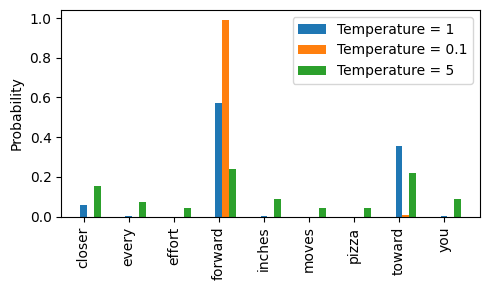

In [33]:
# 원본 확률 분포 & 여러 개의 온도 값으로 스케일 조정한 분포 시각화

# 온도 값
temperatures = [1, 0.1, 5]  # 원본, 낮은 온도, 높은 온도

# 스케일을 조정한 확률 계산
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

# 그래프 그리기
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

# 온도를 낮게(0.1) 조정하면 더 뾰족한 분포 -> torch.argmax에 가까워져 항상 가장 가능성 있는 토큰 선택

### 5.3.2 탑-k 샘플링

- 온도 스케일링
    - 장점: 생성 과정에서 가능성 낮지만 전체적으로 더 흥미롭고 창의적 경로 탐색 가능하게 함
    - 단점: 문법적으로 잘못되거나 논리적으로 잘못된 출력 생성 가능
- 탑-k 샘플링
    - 확률적 샘플링 + 온도 스케일링 결합
    - 샘플링되는 토큰을 가장 가능성 있는 상위 k개 토큰으로 제한
    - 선택되지 않은 모든 로짓을 음의 무한대 값으로 변경
    - ![5-15](img/5-15.png)

In [34]:
# 탑-k 방식 구현
# 먼저 가장 큰 로짓 값 가진 토큰 선택

top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("탑-k 로짓:", top_logits)
print("탑-k 위치:", top_pos)

탑-k 로짓: tensor([6.7500, 6.2800, 4.5100])
탑-k 위치: tensor([3, 7, 0])


In [35]:
# 탑-k 토큰 중 가장 마지막 토큰보다 작은 로짓 값 가진 모든 토큰 로짓 값 음의 무한대로 지정

new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [36]:
# softmax 적용 -> 이를 다음 토큰 확률로 바꿈

topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3 텍스트 생성 함수 수정

In [37]:
# generate_text_simple 함수에 온도 스케일링 & 탑-k 샘플링 적용

def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # for 루프는 이전과 동일. 로짓 받아 마지막 타임 스텝만 사용
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # 탑-k 샘플링으로 로짓을 필터링
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # 온도 스케일링 적용
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)   # 소프트맥스 함수 적용해 확률 얻음
            idx_next = torch.multinomial(probs, num_samples=1)  # 분포에서 샘플링

        # 온도 스케일링을 사용하지 않는 경우 이전처럼 그리디 샘플링을 사용해 다음 토큰을 선택
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:  # eos_id가 지정되어 있고 EoS 토큰을 만나면 생성을 중단
            break

        # 이전과 동일하게 샘플링된 인덱스를 현재 시퀀스 뒤에 추가
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [38]:
# 새로운 generate 함수 테스트

torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you stand to work on surprise, a one of us had gone with random-


## SECTION 5.4 파이토치로 모델 로드 & 저장

- 사전 훈련된 모델을 저장하고 로드하는 방법
    - `torch.save` 함수 사용 -> 모델의 층 & 파라미터를 매핑한 딕셔너리인 state_dict 저장하는 방법 권장

In [39]:
torch.save(model.state_dict(), "model.pth")     # model.pth: state_dict 저장할 파일 이름

In [40]:
# state_dict로 모델 가중치 저장 후 이 가중치를 새로운 GPTModel 객체에 로드 가능

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [41]:
# 옵티마이저 함께 저장 가능
# 적응형 옵티마이저(ex. Adam, AdamW)는 모델 가중치마다 추가적인 파라미터를 저장 -> 나중에 사전 훈련 계속 위해 이 파라미터도 저장해야 함

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [42]:
# 저장된 데이터 먼저 torch.load로 로드, load_state_dict 메서드로 모델 & 옵티마이저 상태 복원 가능

checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

## SECTION 5.5 오픈AI에서 사전 훈련된 가중치 로드

In [43]:
import urllib.request
url = (
    "https://github.com/rickiepark/llm-from-scratch/blob/main/ch05/01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x1dac60b5950>)

In [45]:
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [46]:
print("설정:", settings)                      # LLM 구조의 설정 저장
print("파라미터 딕셔너리 키:", params.keys())    # 실제 가중치 텐서 저장

설정: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
파라미터 딕셔너리 키: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [47]:
print(params["wte"])
print("토큰 임베딩 가중치 텐서의 차원:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
토큰 임베딩 가중치 텐서의 차원: (50257, 768)


In [48]:
# GPT-2 모델 가중치 로드 후 settings와 params 딕셔너리를 GPTModel로 복사

# 모델 크기별 차이 나열한 딕셔너리 생성
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [49]:
# 가장 작은 모델인 "gpt2-small (124M)" 로드 가정
# 앞서 정의한 GPT_CONFIG_124M 설정 model_configs 값으로 업데이트

model_name = "gpt2-small (124M)"  # 모델 이름
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

# 토큰 길이 업데이트, 편향 벡터 사용
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

In [50]:
# OpenAI 가중치를 GPTModel 인스턴스에 있는 가중치 텐서에 할당

def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"크기가 다릅니다. left: {left.shape}, right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [51]:
# params 딕셔너리 가중치를 GPTModel의 인스턴스인 gpt로 로드

import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [52]:
# load_weights_into_gpt 함수 실행, 오픈AI 모델 가중치 gpt로 로드

load_weights_into_gpt(gpt, params)
gpt.to(device);

In [53]:
# generate 함수 사용해 새로운 텍스트 생성

torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you toward finding an ideal new way to practice something!

What makes us want to be on top of that?


